# Customer Retention & Growth Analysis

**Project Overview**  

This project analyzes customer churn for a SaaS company using customer profile, subscription, product usage, support, and churn data. SQL was used to build a customer-level dataset from multiple relational tables, followed by exploratory analysis, hypothesis testing, customer segmentation, and predictive modeling. The goal was to identify churn patterns and evaluate machine learning models capable of identifying customers at risk of leaving.

**Problem Statement**  

When customer retention weakens, a company can lack visibility into which customers are most at risk of churning and the factors driving those decisions. An onboarding experiment had already been implemented in an effort to improve retention, but the results showed no statistically significant reduction in churn. Without a clear understanding of customer behavior and churn risk, retention efforts can be difficult to target effectively. This analysis was conducted to identify the characteristics most closely associated with churn and provide data driven recommendations to support future retention strategies.

## Imports

In [1]:
# Operational
import pandas as pd
import numpy as np

# SQLite
import sqlite3

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( 
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Models
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Constructing the Customer Retention Dataset

The primary objective of this project is to identify factors associated with customer churn and uncover opportunities to improve retention. Because the company's customer data is stored across multiple relational tables, the first step is to consolidate these records into a single analytical dataset. This provides a complete view of each customer's demographics, subscription history, product usage, support activity, and churn outcome.

To accomplish this, the tables are joined using `customer_id`, which uniquely identifies each customer and is present across the relevant tables. This ensures that information from different sources is matched to the correct customer before moving into data cleaning and exploratory analysis.

In [2]:
db_path = r"C:\Users\ShadyEgg\Desktop\python_projects\personal_projects\customer_retention_growth\data\customer_retention_growth.db"

conn = sqlite3.connect(db_path)

query = '''
SELECT
    c.customer_id,
    c.signup_date,
    c.industry,
    c.company_size,
    c.region,
    c.plan_type,
    c.acquisition_channel,
    ch.active,
    ch.churn_date
FROM customers AS c
LEFT JOIN churn AS ch
    ON c.customer_id = ch.customer_id;
'''

customers = pd.read_sql_query(query, conn)

customers.head()

,customer_id,signup_date,industry,company_size,region,plan_type,acquisition_channel,active,churn_date
0,100001,2024-01-13 00:00:00,Retail,Small Business,South,Basic,Referral,1,None
1,100002,2025-05-06 00:00:00,Retail,Mid-Market,West,Basic,Paid Search,1,None
2,100003,2025-12-24 00:00:00,Manufacturing,Mid-Market,West,Basic,Referral,1,None
3,100004,2023-02-10 00:00:00,Healthcare,Small Business,South,Pro,Organic Search,1,None
4,100005,2025-09-02 00:00:00,Retail,Small Business,South,Enterprise,Organic Search,1,None


## Data Inspection

In [3]:
# 14,947 employees, 9 features
customers.shape

(14947, 9)

In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14947 entries, 0 to 14946
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          14947 non-null  int64 
 1   signup_date          14947 non-null  object
 2   industry             14620 non-null  object
 3   company_size         14947 non-null  object
 4   region               14857 non-null  object
 5   plan_type            14947 non-null  object
 6   acquisition_channel  14947 non-null  object
 7   active               14947 non-null  int64 
 8   churn_date           3175 non-null   object
dtypes: int64(2), object(7)
memory usage: 1.0+ MB


In [5]:
# 11,772, 327 and 90 missing values in `churn_date`, `industry` and `region` respectively
customers.isna().sum()

customer_id                0
signup_date                0
industry                 327
company_size               0
region                    90
plan_type                  0
acquisition_channel        0
active                     0
churn_date             11772
dtype: int64

In [6]:
# 162 duplicates observed
customers.duplicated().sum()

np.int64(162)

In [7]:
# `industry` contains inconsistent values
customers['industry'].unique()

array(['Retail', 'Manufacturing', 'Healthcare', 'Technology', 'Finance',
       'RETAIL', 'Professional Services', 'Mfg', 'tech', 'Education',
       'manufacturing', 'healthcare', 'FIN', 'Prof Services', 'TECH',
       'education', 'finance', 'Tech', 'retail', 'Health Care', None,
       'Edu', 'Financial Services', 'HEALTHCARE', 'professional services'],
      dtype=object)

In [8]:
# Date columns are stored as object dtypes 
customers['signup_date'].head()

0    2024-01-13 00:00:00
1    2025-05-06 00:00:00
2    2025-12-24 00:00:00
3    2023-02-10 00:00:00
4    2025-09-02 00:00:00
Name: signup_date, dtype: object

## Customer-Level Data Cleaning

In [9]:
# Instantiate copy
customers_clean = customers.copy()

# Convert date columns to datetime
customers_clean["signup_date"] = pd.to_datetime(customers_clean["signup_date"], errors="coerce")
customers_clean["churn_date"] = pd.to_datetime(customers_clean["churn_date"], errors="coerce")

# Standardize `industry` labels
industry_map = {
    "healthcare":"Healthcare",
    "health care":"Healthcare",
    "finance":"Finance",
    "fin":"Finance",
    "financial services":"Finance",
    "education":"Education",
    "edu":"Education",
    "retail":"Retail",
    "technology":"Technology",
    "tech":"Technology",
    "manufacturing":"Manufacturing",
    "mfg":"Manufactoring",
    "professional services":"Professional Services",
    "prof services":"Professional Services"
}

customers_clean["industry"] = (
    customers_clean["industry"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(industry_map)
)

# Drop exact duplicate rows
customers_clean = customers_clean.drop_duplicates().reset_index(drop=True)

customers_clean.head()

,customer_id,signup_date,industry,company_size,region,plan_type,acquisition_channel,active,churn_date
0,100001,2024-01-13,Retail,Small Business,South,Basic,Referral,1,NaT
1,100002,2025-05-06,Retail,Mid-Market,West,Basic,Paid Search,1,NaT
2,100003,2025-12-24,Manufacturing,Mid-Market,West,Basic,Referral,1,NaT
3,100004,2023-02-10,Healthcare,Small Business,South,Pro,Organic Search,1,NaT
4,100005,2025-09-02,Retail,Small Business,South,Enterprise,Organic Search,1,NaT


## Missing Values

Categorical variables with a small number of missing observations were assigned an "Unknown" category to preserve customer records. Missing churn dates were retained because active customers are not expected to have a churn date.
```
Variable	Missing %	                   Action
industry	2.1%	                           Create "Unknown" category
company_size	1.8%	                           Create "Unknown" category
signup_date	0.1%	                           Investigate and remove if invalid
churn_date	Expected for active customers	   Leave as missing
```

## Monthly Customer Metrics

Tables such as subscriptions, usage metrics, and support tickets contain multiple records per customer over time. Leaving the data at this monthly level will create multiple rows associated with the same target and will likely distort the analysis and downstream modeling.

CTEs are used to summarize these features at the customer level before joining the tables together using SQLite. It is worth mentioning that a collapsing of these customer associated statistics into averages can introduce a level of loss of granularity or detail as features that might be preserving time-based behavior would not be accounted for. 

The following SQL extraction keeps the original cusomter-level aggregation but adds recent behavior features to reduce the loss of detail caused by summarizing monthly records. `last_month_logins` from the `usage_metrics` table, captures recent product engagement, while `tickets_last_90_days` from the `support_tickets` table, captures recent customer friction. These two features help preserve signals that may be hidden by liftetime averages or totals without getting too complex. 

In [10]:
customer_metrics_query = """
WITH revenue AS (
    SELECT
        customer_id,
        SUM(monthly_revenue) AS lifetime_revenue,
        AVG(monthly_revenue) AS avg_monthly_revenue,
        SUM(refund_amount) AS total_refunds,
        SUM(upgraded) AS total_upgrades,
        SUM(downgraded) AS total_downgrades,
        COUNT(*) AS months_billed
    FROM subscriptions
    GROUP BY customer_id
),

usage AS (
    SELECT
        customer_id,
        AVG(logins) AS avg_monthly_logins,
        AVG(active_days) AS avg_active_days,
        AVG(features_used) AS avg_features_used,
        AVG(avg_session_minutes) AS avg_session_minutes,

        -- Recent usage feature
        MAX(CASE
            WHEN month = (
                SELECT MAX(month)
                FROM usage_metrics
            )
            THEN logins
        END) AS last_month_logins
    FROM usage_metrics
    GROUP BY customer_id
),

support AS (
    SELECT
        customer_id,
        COUNT(*) AS ticket_count,
        AVG(resolution_hours) AS avg_resolution_hours,

        -- Recent support feature
        SUM(CASE
            WHEN created_date >= DATE('2025-12-31', '-90 days')
            THEN 1
            ELSE 0
        END) AS tickets_last_90_days

    FROM support_tickets
    GROUP BY customer_id
)

SELECT
    c.customer_id,
    c.signup_date,
    c.industry,
    c.company_size,
    c.region,
    c.plan_type,
    c.acquisition_channel,

    COALESCE(r.lifetime_revenue, 0) AS lifetime_revenue,
    COALESCE(r.avg_monthly_revenue, 0) AS avg_monthly_revenue,
    COALESCE(r.total_refunds, 0) AS total_refunds,
    COALESCE(r.total_upgrades, 0) AS total_upgrades,
    COALESCE(r.total_downgrades, 0) AS total_downgrades,
    COALESCE(r.months_billed, 0) AS months_billed,

    COALESCE(u.avg_monthly_logins, 0) AS avg_monthly_logins,
    COALESCE(u.avg_active_days, 0) AS avg_active_days,
    COALESCE(u.avg_features_used, 0) AS avg_features_used,
    COALESCE(u.avg_session_minutes, 0) AS avg_session_minutes,
    COALESCE(u.last_month_logins, 0) AS last_month_logins,

    COALESCE(s.ticket_count, 0) AS ticket_count,
    COALESCE(s.avg_resolution_hours, 0) AS avg_resolution_hours,
    COALESCE(s.tickets_last_90_days, 0) AS tickets_last_90_days,

    ch.active,
    ch.churn_date

FROM customers AS c
LEFT JOIN revenue AS r
    ON c.customer_id = r.customer_id
LEFT JOIN usage AS u
    ON c.customer_id = u.customer_id
LEFT JOIN support AS s
    ON c.customer_id = s.customer_id
LEFT JOIN churn AS ch
    ON c.customer_id = ch.customer_id;
"""

df = pd.read_sql_query(customer_metrics_query, conn)

df.head()

,customer_id,signup_date,industry,company_size,region,plan_type,acquisition_channel,lifetime_revenue,avg_monthly_revenue,total_refunds,total_upgrades,total_downgrades,months_billed,avg_monthly_logins,avg_active_days,avg_features_used,avg_session_minutes,last_month_logins,ticket_count,avg_resolution_hours,tickets_last_90_days,active,churn_date
0,100001,2024-01-13 00:00:00,Retail,Small Business,South,Basic,Referral,"1,088.90",45.37,0,0,0,24,16.46,9.75,3.88,19.68,15,10,16.34,1,1,None
1,100002,2025-05-06 00:00:00,Retail,Mid-Market,West,Basic,Paid Search,647.19,80.90,0,0,0,8,19.88,12.75,4.38,23.95,16,3,10.60,0,1,None
2,100003,2025-12-24 00:00:00,Manufacturing,Mid-Market,West,Basic,Referral,86.04,86.04,0,0,0,1,12.00,8.00,2.00,12.65,12,1,5.54,1,1,None
3,100004,2023-02-10 00:00:00,Healthcare,Small Business,South,Pro,Organic Search,"4,722.39",134.93,0,1,1,35,22.11,12.20,5.59,21.68,7,10,9.68,1,1,None
4,100005,2025-09-02 00:00:00,Retail,Small Business,South,Enterprise,Organic Search,"1,897.87",474.47,0,0,0,4,21.75,13.00,6.50,23.12,24,3,7.02,3,1,None


In [11]:
# Instantiating a new df
df_clean = df.copy()

# Datetime conversion
df_clean["signup_date"] = pd.to_datetime(df_clean["signup_date"], errors="coerce")
df_clean["churn_date"] = pd.to_datetime(df_clean["churn_date"], errors="coerce")

# Standardize `industry`
df_clean["industry"] = (
    df_clean["industry"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(industry_map)
)

# Removing duplicate customer rows
df_clean = df_clean.drop_duplicates(subset=["customer_id"]).reset_index(drop=True)

# Target variable
df_clean["churned"] = np.where(df_clean["active"]==0,1,0)

# Creating customer tenure in months
analysis_date = pd.Timestamp("2025-12-31")
df_clean["tenure_days"] = np.where(
    df_clean["churn_date"].notna(),
    (df_clean["churn_date"] - df_clean["signup_date"]).dt.days,
    (analysis_date - df_clean["signup_date"]).dt.days
)

df_clean["tenure_months"] = df_clean["tenure_days"] / 30.44

df_clean.head()

,customer_id,signup_date,industry,company_size,region,plan_type,acquisition_channel,lifetime_revenue,avg_monthly_revenue,total_refunds,total_upgrades,total_downgrades,months_billed,avg_monthly_logins,avg_active_days,avg_features_used,avg_session_minutes,last_month_logins,ticket_count,avg_resolution_hours,tickets_last_90_days,active,churn_date,churned,tenure_days,tenure_months
0,100001,2024-01-13,Retail,Small Business,South,Basic,Referral,"1,088.90",45.37,0,0,0,24,16.46,9.75,3.88,19.68,15,10,16.34,1,1,NaT,0,718.00,23.59
1,100002,2025-05-06,Retail,Mid-Market,West,Basic,Paid Search,647.19,80.90,0,0,0,8,19.88,12.75,4.38,23.95,16,3,10.60,0,1,NaT,0,239.00,7.85
2,100003,2025-12-24,Manufacturing,Mid-Market,West,Basic,Referral,86.04,86.04,0,0,0,1,12.00,8.00,2.00,12.65,12,1,5.54,1,1,NaT,0,7.00,0.23
3,100004,2023-02-10,Healthcare,Small Business,South,Pro,Organic Search,"4,722.39",134.93,0,1,1,35,22.11,12.20,5.59,21.68,7,10,9.68,1,1,NaT,0,"1,055.00",34.66
4,100005,2025-09-02,Retail,Small Business,South,Enterprise,Organic Search,"1,897.87",474.47,0,0,0,4,21.75,13.00,6.50,23.12,24,3,7.02,3,1,NaT,0,120.00,3.94


In [12]:
overall_churn_rate = df_clean["churned"].mean()
overall_churn_rate

np.float64(0.21183632059519783)

In [13]:
# Health check
df_clean[[
    "lifetime_revenue",
    "avg_monthly_revenue",
    "avg_monthly_logins",
    "avg_active_days",
    "ticket_count",
    "tenure_months",
    "churned"
]].describe()

,lifetime_revenue,avg_monthly_revenue,avg_monthly_logins,avg_active_days,ticket_count,tenure_months,churned
count,"14,785.00","14,785.00","14,785.00","14,785.00","14,785.00","14,785.00","14,785.00"
mean,"4,144.65",241.50,22.51,14.38,6.54,15.32,0.21
std,"7,784.83",348.27,6.03,4.13,6.47,9.97,0.41
min,34.46,32.31,0.00,0.00,0.00,0.00,0.00
25%,695.18,55.62,18.00,11.50,2.00,6.60,0.00
50%,"1,652.00",125.53,22.05,14.17,5.00,13.99,0.00
75%,"4,030.11",250.12,26.43,17.00,9.00,23.29,0.00
max,"94,207.64","2,657.76",52.00,30.00,54.00,35.97,1.00


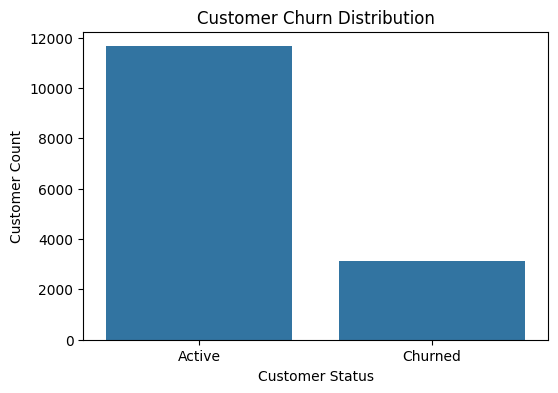

In [14]:
plt.figure(figsize=(6,4))

ax=sns.countplot(data=df_clean, x="churned")

ax.set_xticks([0,1])
ax.set_xticklabels(["Active", "Churned"])

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Customer Count")

plt.show()

In [15]:
df_clean["churned"].sum() / 14785

np.float64(0.21183632059519783)

The target variable `churned` has approximately a 79%-21% class imbalance. This is not a terrible split for downstream modeling, however, a highly imbalanced target can make model accuracy misleading. More attention to metrics such as precision, recall, F1-score, and ROC-AUC during modeling should be considered.

## Customer Segmentation by Business Category

In [16]:
df_clean.groupby("plan_type")["churned"].mean().sort_values(ascending=False)

plan_type
Basic        0.29
Pro          0.17
Enterprise   0.05
Name: churned, dtype: float64

In [17]:
df_clean.groupby("company_size")["churned"].mean().sort_values(ascending=False)

company_size
Small Business   0.26
Mid-Market       0.19
Enterprise       0.03
Name: churned, dtype: float64

In [18]:
df_clean.groupby("acquisition_channel")["churned"].mean().sort_values(ascending=False)

acquisition_channel
Paid Search      0.24
Referral         0.21
Organic Search   0.21
Direct           0.20
Social           0.20
Partner          0.20
Name: churned, dtype: float64

Customer characteristics associated with company size and subscription tier are more strongly related to churn than acquisition source. Basic plan customers and small businesses exhibit substantially higher churn rates, while `Enterprise` customers show the strongest retention.

## Support Burden and Churn

Defining high support burden as customers in the top 25% of ticket counts.

In [19]:
# Instantiating threshold
ticket_threshold = df_clean["ticket_count"].quantile(0.75)

# Binary indicator: High=1, low=0
df_clean["high_support_burden"] = np.where(
    df_clean["ticket_count"] >= ticket_threshold,
    1,
    0
)
 # Table
support_churn_table = pd.crosstab(
    df_clean["high_support_burden"],
    df_clean["churned"],
    margins=True
)

support_churn_table

churned,0,1,All
high_support_burden,,,
0,8330,2592,10922
1,3323,540,3863
All,11653,3132,14785


In [20]:
high_support = df_clean[df_clean["high_support_burden"] == 1]["churned"]
low_support = df_clean[df_clean["high_support_burden"] == 0]["churned"]

count = np.array([high_support.sum(), low_support.sum()])
nobs = np.array([high_support.count(), low_support.count()])

z_stat, p_value = proportions_ztest(count, nobs)

z_stat, p_value

(np.float64(-12.750846058237798), np.float64(3.08380129710049e-37))

Customers in the high support burden group exhibited a significantly different churn rate than customers with lower support demand. The two-proportion z-test produced a statistically significant result, suggesting a meaningful relationship between support activity and churn behavior. However, support burden alone should not be interpreted as a direct cause of churn, as ticket volume may also reflect differences in customer engagement, account maturity, or underlying product issues. Interestingly, the direction of the relationship suggests that customers with higher support engagement may not necessarily be more likely to churn, highlighting the importance of examining customer context rather than ticket volume alone.

## A/B Testing: Onboarding Experiment

In [21]:
experiment_query = '''
SELECT
    e.customer_id,
    e.experiment_group,
    e.assignment_date,
    ch.active,
    ch.churn_date
FROM experiments AS e
LEFT JOIN churn AS ch
    ON e.customer_id = ch.customer_id;
'''

experiment = pd.read_sql_query(experiment_query, conn)

experiment["experiment_group"] = (
    experiment["experiment_group"]
    .astype("string")
    .str.strip()
    .str.lower()
)

experiment["churned"] = np.where(experiment["active"] == 0, 1, 0)

experiment.groupby("experiment_group")["churned"].agg(["mean", "count"])

,mean,count
experiment_group,,
control,0.10,933
treatment,0.12,938


In [22]:
control = experiment[experiment["experiment_group"] == "control"]["churned"]
treatment = experiment[experiment["experiment_group"] == "treatment"]["churned"]

count = np.array([treatment.sum(), control.sum()])
nobs = np.array([treatment.count(), control.count()])

z_stat, p_value = proportions_ztest(count, nobs)

z_stat, p_value

(np.float64(0.9173498953394718), np.float64(0.3589593192927256))

In [23]:
control_ci = proportion_confint(control.sum(), control.count(), alpha=0.05, method="wilson")
treatment_ci = proportion_confint(treatment.sum(), treatment.count(), alpha=0.05, method="wilson")

control_ci, treatment_ci

((0.08597786463420207, 0.125201366342338),
 (0.09822468434689413, 0.1394389444139084))

**Onboarding experiment diagnostic**

Customers assigned to the treatment group show a slightly higher churn rate (12%) than customers in the control group (10%). A two-proportion z-test clarified this observation in producing a p-value of 0.359, far above the level of significance chosen for this analysis (0.05), indicating that the observed difference is not statistically significant. The overlapping confidence intervals further suggests that the true churn rates between the two groups may be similar. Based on the results, there is insufficent evidence that the new onboarding feature improved customer retention. 

## Customer Segmentation Through K-Means

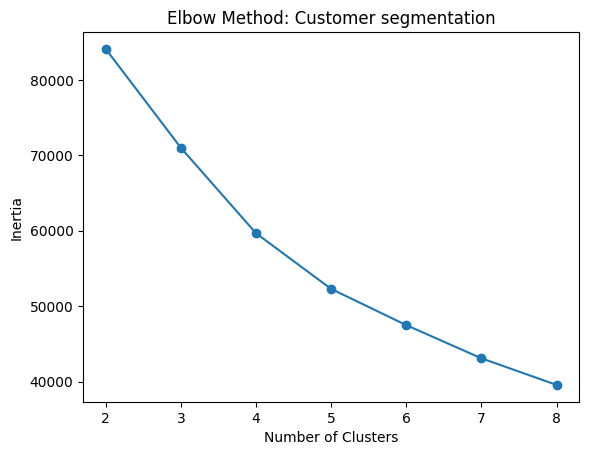

In [24]:
# Selected numerical features
segmentation_features = [
    "lifetime_revenue",
    "avg_monthly_revenue",
    "avg_monthly_logins",
    "avg_active_days",
    "avg_features_used",
    "ticket_count",
    "avg_resolution_hours",
    "tenure_months"
]

# Clustering input table
x_seg = df_clean[segmentation_features].fillna(0)

# Standardize
scaler = StandardScaler()
x_seg_scaled = scaler.fit_transform(x_seg)

inertia = []

# Model fitting
for k in range(2,9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_seg_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,9), inertia, marker="o")
plt.title("Elbow Method: Customer segmentation")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

Substantial reductions in within-cluster variance begin through four clusters, after which improvements in cluster compactness begin to diminish slowing considerably beyond four to five clusters. Four clusters will be selected as a balance between cluster quality and interpretability.

In [25]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df_clean["customer_segment"] = kmeans.fit_predict(x_seg_scaled)

segment_profile = df_clean.groupby("customer_segment")[segmentation_features + ["churned"]]\
    .mean().round(2)

segment_profile

,lifetime_revenue,avg_monthly_revenue,avg_monthly_logins,avg_active_days,avg_features_used,ticket_count,avg_resolution_hours,tenure_months,churned
customer_segment,,,,,,,,,
0,"3,162.36",119.07,20.41,13.08,4.81,11.82,14.87,25.89,0.17
1,770.41,87.36,18.50,11.71,4.22,3.32,12.24,8.55,0.33
2,"4,895.15",370.79,28.00,18.10,6.88,4.17,12.95,12.52,0.14
3,"27,205.52","1,208.58",32.93,20.66,8.59,14.58,14.36,24.58,0.01


**Table interpretation**
```
Segment	  Revenue	Engagement	Churn
1	  Low	        Low	        33%
0	  Medium	Medium	        17%
2	  High	        High	        14%
3	  Very High	Very High	1%
```
There is a clear and consistent relationship in that customers who engage more deeply with the platform generate more revenue and are substantially less likely to churn. 

On the high end, cluster 3 clearly shows that revenue, engagement and retention all appear strongly aligned and likely represent mature (high tenure), deeply integrated (high activity) accounts deriving substantial value from the platform. Supporting this cluster should be a focus.

Cluster 2 appears to contain a healthy group of customers who likely represent a pipeline of accounts that could eventually grow into the highest value segment (cluster 3). Upselling and expansion should be the focus for this cluster to promote movement to cluster 3. 

Cluster 1 appears to represent the newest, at-risk customers who have not fully adopted the platform. With a combination of low engagement, low feature usage, and elevated churn, this suggests they are struggling to see value from the product. Making this cluster the primary retention target should be a focus.

Cluster 0 is interesting because these customers have been around for a long time (high tenure) and generate decent revenue however, they continue to require substantial support resources and experience higher churn than other customer groups. Product friction or unresolved customer pain points may be contributing factors and warrant further investigation. 

## Churn Model Feature Preparation

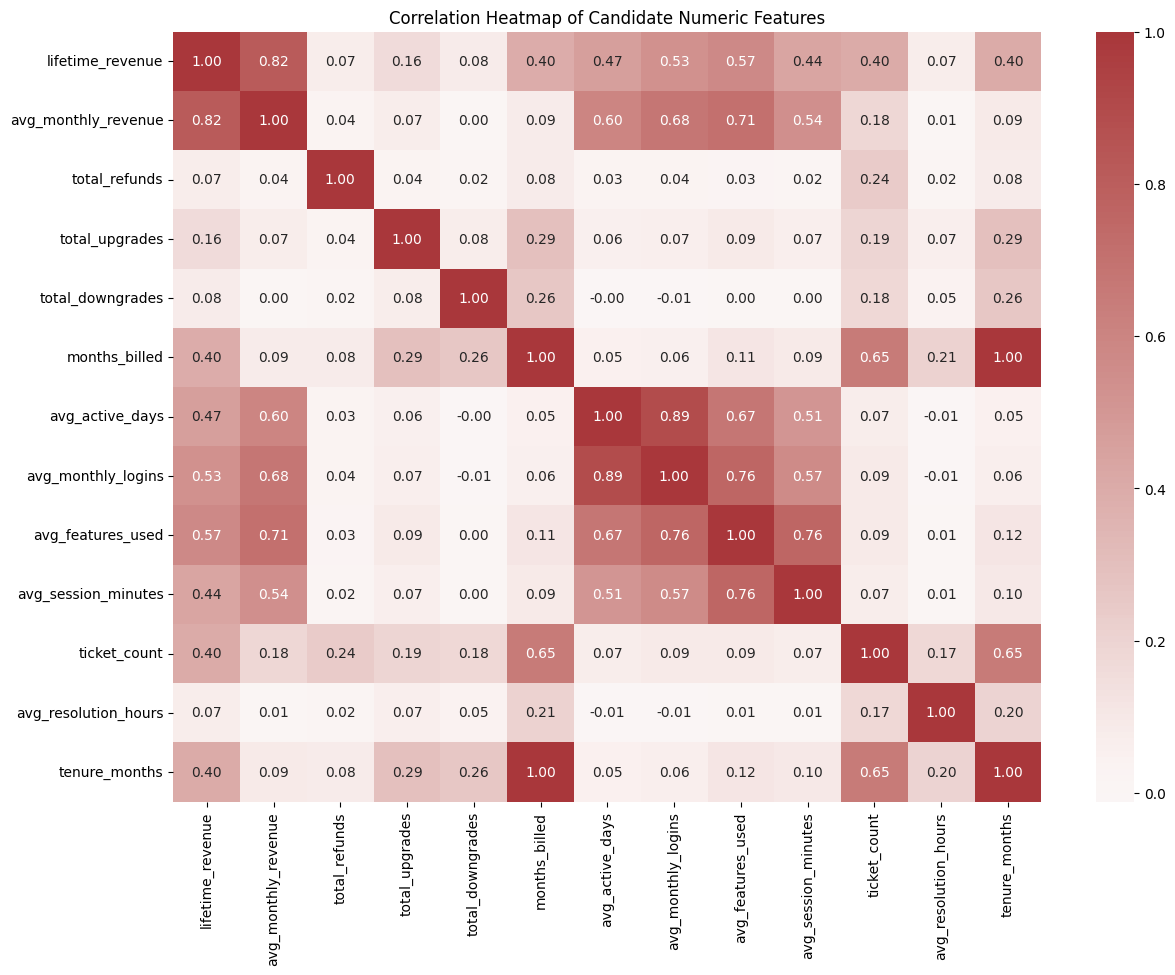

In [26]:
# Candidate numeric features for collinearity review
corr_features = [
    "lifetime_revenue",
    "avg_monthly_revenue",
    "total_refunds",
    "total_upgrades",
    "total_downgrades",
    "months_billed",
    "avg_active_days",
    "avg_monthly_logins",
    "avg_features_used",
    "avg_session_minutes",
    "ticket_count",
    "avg_resolution_hours",
    "tenure_months"
]

corr_df = df_clean[corr_features].copy()

corr_matrix = corr_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
)

plt.title("Correlation Heatmap of Candidate Numeric Features")
plt.show()

Correlation analysis reveals perfect collinearity between `months_billed` and `tenure_months` (`r = 1.00`). Because both variables capture nearly identical information, `months_billed` will be removed from the modeling dataset. A second highly correlated pair, `avg_active_days` and `avg_monthly_logins` (`r = 0.89`), was also investigated. However, removing `avg_active_days` resulted in a substantial decline in churn detection performance, suggesting that it provides meaningful information beyond login frequency alone. While the two variables are strongly related, they capture different aspects of customer engagement, so `avg_active_days` was retained in the final model.

The variables, `active` and `churn_date`, also have to be excluded from the predictor matrix otherwise either variable could introduce overly optimistic model performance. The target variable `churned` is derived from `active` while `churn_date` directly reveals whether a customer ultimately churned which is cheating. 

In [27]:
# Variables
model_features = [
    "lifetime_revenue",
    "avg_monthly_revenue",
    "total_refunds",
    "total_upgrades",
    "total_downgrades",
    "avg_active_days",
    "avg_monthly_logins",
    "avg_features_used",
    "avg_session_minutes",
    "ticket_count",
    "avg_resolution_hours",
    "tenure_months",
    "company_size",
    "plan_type",
    "acquisition_channel",
    "customer_segment"
]

# Instantiating model object
model_df = df_clean[model_features + ["churned"]].copy()

# Dummy encode categoricals
model_df = pd.get_dummies(
    model_df,
    columns=["company_size", "plan_type", "acquisition_channel", "customer_segment"],
    drop_first=True
)

# Handling remaining missing values
model_df = model_df.fillna(0)

# Set target and predictors
x = model_df.drop(columns=["churned"])      # Feature matrix
y = model_df["churned"]                     # Target vector

# Split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

x_train.shape, x_test.shape

((11088, 24), (3697, 24))

## Model Training

**Logistic Regression Baseline**

In [28]:
# Standardize
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

log_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)

log_model.fit(x_train_scaled, y_train)

log_probs = log_model.predict_proba(x_test_scaled)[:,1]
log_preds = np.where(log_probs >= 0.50, 1, 0)


print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.90      0.59      0.71      2914
           1       0.33      0.74      0.46       783

    accuracy                           0.62      3697
   macro avg       0.61      0.67      0.58      3697
weighted avg       0.78      0.62      0.66      3697



In [29]:
for threshold in [0.50, 0.40, 0.35, 0.30, 0.30, 0.25]:
    preds = np.where(log_probs >= threshold, 1, 0)
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, preds))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      0.59      0.71      2914
           1       0.33      0.74      0.46       783

    accuracy                           0.62      3697
   macro avg       0.61      0.67      0.58      3697
weighted avg       0.78      0.62      0.66      3697


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.43      0.59      2914
           1       0.29      0.88      0.44       783

    accuracy                           0.52      3697
   macro avg       0.61      0.66      0.51      3697
weighted avg       0.80      0.52      0.56      3697


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.95      0.36      0.52      2914
           1       0.28      0.93      0.43       783

    accuracy                           0.48      3697
   macro avg       0.61      0.64      0.47      3697
weighted avg       0.81  

The Logistic Regression model initially produced convergence warnings, prompting an investigation into feature scaling and multicollinearity. Correlation analysis revealed perfect collinearity between `months_billed` and `tenure_months`, leading to the removal of `months_billed`. A second highly correlated pair, `avg_active_days` and `avg_monthly_logins`, was also investigated. However, removing `avg_active_days` significantly reduced churn detection performance, suggesting that it captures meaningful engagement behavior beyond login frequency alone, so both features were retained.

Although the dataset was only moderately imbalanced (79% active, 21% churned), the initial model struggled to identify churned customers. Applying `class_weight="balanced"` substantially improved churn detection by increasing the model's emphasis on the minority class.

Threshold testing highlighted the tradeoff between churn detection and false positives. Lower thresholds increased recall but reduced precision and overall accuracy. The default threshold of 0.50 provided the best balance between precision and recall and was retained for the final model.

The final model successfully identified most churned customers while maintaining reasonable overall performance, making it a practical tool for targeting retention efforts before customers leave.

**Decision Tree Model**

In [30]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(x_train, y_train)

tree_preds = tree_model.predict(x_test)

print(classification_report(y_test, tree_preds))

              precision    recall  f1-score   support

           0       0.91      0.58      0.71      2914
           1       0.33      0.79      0.47       783

    accuracy                           0.62      3697
   macro avg       0.62      0.68      0.59      3697
weighted avg       0.79      0.62      0.66      3697



After addressing class imbalance, the Decision Tree model achieved performance comparable to Logistic Regression. The model correctly identified 79% of churned customers while maintaining a churn F1-score of 0.47. Although precision remaining relatively low is an expected tradeoff, the strong recall suggests that the model is effective at identifying customers at risk of leaving. Compared with Logistic Regression, the Decision Tree produced a slightly higher recall and F1-score, indicating a modest improvement in churn detection performance.

**Random Forest Model**

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

rf_preds = rf_model.predict(x_test)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.91      0.60      0.72      2914
           1       0.34      0.78      0.47       783

    accuracy                           0.64      3697
   macro avg       0.63      0.69      0.60      3697
weighted avg       0.79      0.64      0.67      3697



The Random Forest model correctly identified 78% of churned customers while achieving an F1-score of 0.47 for the churn class. Although precision remained relatively low, indicating a high number of false positive churn predictions, the model successfully captured the majority of customers who ultimately left the service. This tradeoff is acceptable in a customer retention setting, where failing to identify an at-risk customer is often more costly than contacting a customer who would have remained active.

## Model Comparison

In [32]:
# Predicted probabilities for class 1/churn
log_probs = log_model.predict_proba(x_test_scaled)[:, 1]
tree_probs = tree_model.predict_proba(x_test)[:, 1]
rf_probs = rf_model.predict_proba(x_test)[:, 1]

def evaluate_classifier(model_name, y_true, y_pred, y_prob):
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

    return metrics

model_results = []

model_results.append(
    evaluate_classifier("Logistic Regression", y_test, log_preds, log_probs)
)

model_results.append(
    evaluate_classifier("Decision Tree", y_test, tree_preds, tree_probs)
)

model_results.append(
    evaluate_classifier("Random Forest", y_test, rf_preds, rf_probs)
)

results_df = pd.DataFrame(model_results).sort_values("f1", ascending=False)

results_df.round(3)

,model,accuracy,precision,recall,f1,roc_auc
2,Random Forest,0.64,0.34,0.78,0.47,0.75
1,Decision Tree,0.62,0.34,0.79,0.47,0.73
0,Logistic Regression,0.62,0.33,0.74,0.46,0.73


All three models performed similarly, suggesting that customer churn is challenging to predict with the available data. The Decision Tree identified the highest percentage of churned customers, while the Random Forest achieved the strongest overall performance (ROC AUC score of 0.75), although the differences between models were relatively modest. Because all three models produced similar ROC AUC, precision, recall, and F1 scores, the results suggest that the available features may be a greater limitation than the choice of algorithm.

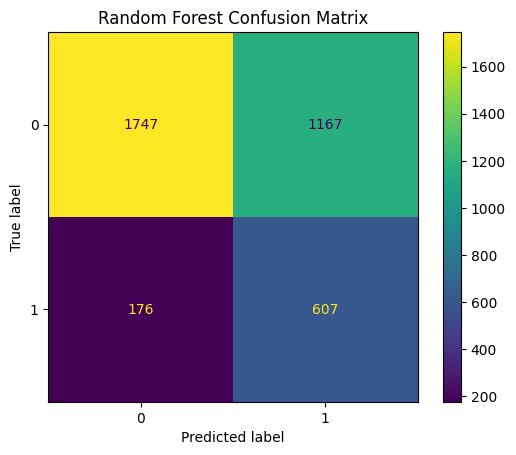

In [33]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, rf_preds)

plt.title("Random Forest Confusion Matrix")
plt.show()

The Random Forest model correctly identified 607 of 783 churned customers while missing 176 churners. Although the model produced a relatively high number of false positive churn predictions, it successfully detected the majority of customers who ultimately left the service. This behavior is consistent with the model's high churn recall (78%) and supports its use as a customer retention tool where identifying at-risk customers is a higher priority than minimizing false alarms.

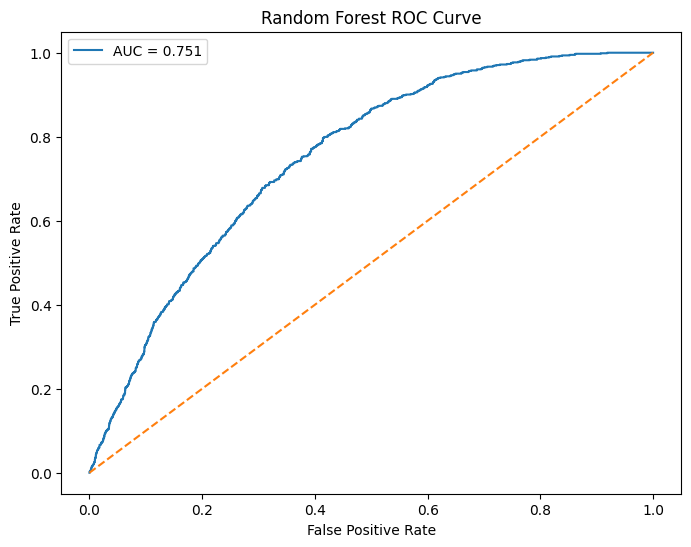

ROC AUC Score: 0.751


In [34]:
## ROC Curve and AUC

rf_probs = rf_model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, rf_probs)
auc = roc_auc_score(y_test, rf_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.show()

print(f"ROC AUC Score: {auc:.3f}")

In [35]:
## Feature Importance

feature_importance = pd.DataFrame({
    "feature": x_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
0,lifetime_revenue,0.22
1,avg_monthly_revenue,0.17
11,tenure_months,0.14
7,avg_features_used,0.09
21,customer_segment_1,0.07
5,avg_active_days,0.07
6,avg_monthly_logins,0.07
8,avg_session_minutes,0.05
9,ticket_count,0.03
10,avg_resolution_hours,0.02


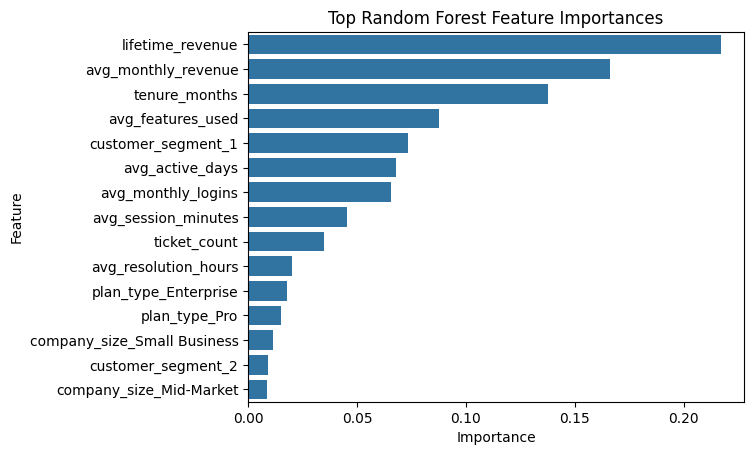

In [37]:
sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [36]:
# Tableau Export
feature_importance_tableau = feature_importance.head(10).copy()

feature_importance_tableau["feature"] = (
    feature_importance_tableau["feature"]
    .str.replace("_"," ")
    .str.title()
)

feature_importance_tableau.to_csv(
    r"C:\Users\ShadyEgg\Desktop\python_projects\personal_projects\customer_retention_growth\data\feature_importance_tableau.csv",
    index=False
)

feature_importance_tableau
    

,feature,importance
0,Lifetime Revenue,0.22
1,Avg Monthly Revenue,0.17
11,Tenure Months,0.14
7,Avg Features Used,0.09
21,Customer Segment 1,0.07
5,Avg Active Days,0.07
6,Avg Monthly Logins,0.07
8,Avg Session Minutes,0.05
9,Ticket Count,0.03
10,Avg Resolution Hours,0.02


Feature importance analysis showed that revenue, tenure, and product engagement were the strongest predictors of churn. Lifetime revenue, average monthly revenue, and tenure months ranked as the most influential features, followed by usage metrics such as features used, active days, and monthly logins. Customer segmentation also contributed predictive value, particularly `customer_segment_1`, which represented newer, lower-value, and less engaged customers with the highest observed churn rate. This suggests that behavioral customer segments captured meaningful differences in churn risk beyond individual usage metrics alone. In contrast, company size and plan type contributed relatively little predictive value, indicating that customer behavior was a stronger indicator of churn than customer demographics.

In [38]:
# Exporting
tableau_export = df_clean.copy()

tableau_export["rf_churn_prediction"] = rf_model.predict(x)
tableau_export["rf_churn_probability"] = rf_model.predict_proba(x)[:,1]

tableau_export.to_csv(r"C:\Users\ShadyEgg\Desktop\python_projects\personal_projects\customer_retention_growth\data\tableau_customer_retention_export.csv", index=False)

tableau_export.head()

,customer_id,signup_date,industry,company_size,region,plan_type,acquisition_channel,lifetime_revenue,avg_monthly_revenue,total_refunds,total_upgrades,total_downgrades,months_billed,avg_monthly_logins,avg_active_days,avg_features_used,avg_session_minutes,last_month_logins,ticket_count,avg_resolution_hours,tickets_last_90_days,active,churn_date,churned,tenure_days,tenure_months,high_support_burden,customer_segment,rf_churn_prediction,rf_churn_probability
0,100001,2024-01-13,Retail,Small Business,South,Basic,Referral,"1,088.90",45.37,0,0,0,24,16.46,9.75,3.88,19.68,15,10,16.34,1,1,NaT,0,718.00,23.59,1,0,1,0.62
1,100002,2025-05-06,Retail,Mid-Market,West,Basic,Paid Search,647.19,80.90,0,0,0,8,19.88,12.75,4.38,23.95,16,3,10.60,0,1,NaT,0,239.00,7.85,0,1,1,0.66
2,100003,2025-12-24,Manufacturing,Mid-Market,West,Basic,Referral,86.04,86.04,0,0,0,1,12.00,8.00,2.00,12.65,12,1,5.54,1,1,NaT,0,7.00,0.23,0,1,0,0.13
3,100004,2023-02-10,Healthcare,Small Business,South,Pro,Organic Search,"4,722.39",134.93,0,1,1,35,22.11,12.20,5.59,21.68,7,10,9.68,1,1,NaT,0,"1,055.00",34.66,1,0,0,0.17
4,100005,2025-09-02,Retail,Small Business,South,Enterprise,Organic Search,"1,897.87",474.47,0,0,0,4,21.75,13.00,6.50,23.12,24,3,7.02,3,1,NaT,0,120.00,3.94,0,1,0,0.38


In [39]:
conn.close()

**Executive Summary**  

Customers with lower revenue, shorter tenure, and lower product engagement were significantly more likely to churn. Customer segmentation further revealed a high risk group characterized by lower value, less engaged customers with the highest observed churn rate. An A/B test evaluating the proposed onboarding intervention found no statistically significant difference in churn outcomes between treatment and control groups, suggesting that the tested onboarding changes were not effective in improving retention. Three classification models were evaluated, with the Random Forest model achieving the strongest overall performance, producing the highest accuracy and ROC AUC score among the evaluated models, although performance differences between models were relatively modest. Feature importance analysis showed that revenue, tenure, engagement, and customer segment membership were the most influential predictors of churn.

**Recommendations**  

- Segment 1 customers should be the primary focus of retention efforts, as they experienced the highest churn rates and the lowest engagement levels.
- Customers averaging fewer than 20 monthly logins exhibit substantially higher predicted churn risk. Retention efforts should prioritize low-login customers through onboarding campaigns, feature adoption outreach, and intervention resources.
- The onboarding experiment did not significantly improve retention, suggesting that a different approach may be needed.
- The model identified 7,113 customers in the High Risk segment representing approximately $6.9M in revenue exposure. Prioritizing retention efforts on this segment offers the highest potential return on intervention resources.
- Customer behavior was a much stronger indicator of churn than demographic characteristics, so future retention strategies should focus on engagement and product adoption.